# Determining Ideal Simulation Size

## Imports and constants

In [1]:
import numpy as np
from astropy import units as u, constants as c
from matplotlib import pyplot as plt

import sys
sys.path.append("..")
from oskareor.skalow_calc import SKAMath as omath, EoRCosmology as Cosmo

In [2]:
STATION_DIAMETER = 38 * u.m

## Calculating the SKA primary beam size

For the airy disk we will use the calculation for the first minimum, as that is where we can ensure the primary beam edges fully obscure any corner or side-of-box data.

In [3]:
# Create array of redshift values from 5 to 12 inclusive, use 71 entries (i.e. a redshift step of 0.1)
zs = np.linspace(5, 12, 71)

# Frequencies and wavelengths
fs = omath.FREQ_21CM / (zs + 1)
λs = c.c / fs

# Airy disk first minimum
θs = np.asin(1.22 * λs / STATION_DIAMETER).to(u.deg)

print(θs)

[2.33011909 2.36897637 2.40783474 2.44669422 2.48555483 2.52441658
 2.56327949 2.60214358 2.64100887 2.67987538 2.71874312 2.75761211
 2.79648238 2.83535393 2.87422679 2.91310097 2.95197649 2.99085338
 3.02973164 3.0686113  3.10749237 3.14637487 3.18525883 3.22414426
 3.26303117 3.30191958 3.34080952 3.379701   3.41859404 3.45748866
 3.49638487 3.53528269 3.57418215 3.61308325 3.65198603 3.69089049
 3.72979665 3.76870454 3.80761417 3.84652555 3.88543871 3.92435367
 3.96327044 4.00218904 4.04110949 4.08003181 4.11895602 4.15788213
 4.19681016 4.23574014 4.27467207 4.31360598 4.35254188 4.3914798
 4.43041976 4.46936176 4.50830583 4.54725199 4.58620025 4.62515064
 4.66410317 4.70305786 4.74201474 4.7809738  4.81993509 4.8588986
 4.89786437 4.93683241 4.97580275 5.01477538 5.05375035] deg


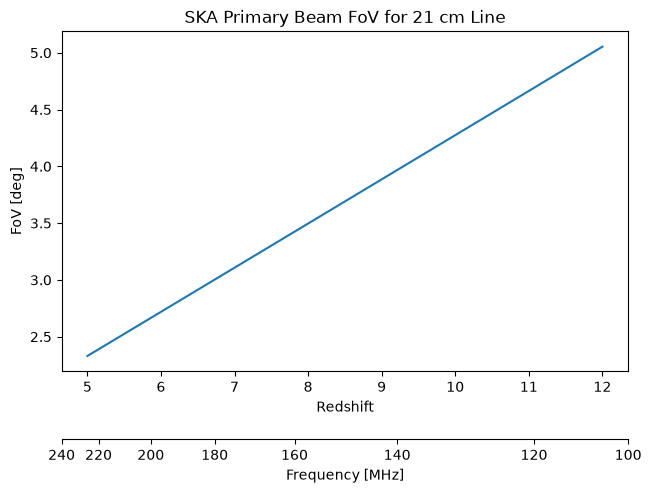

In [22]:
fig, ax = plt.subplots(layout='constrained')

ax.plot(zs, θs)
ax.set_xlabel("Redshift")
ax.set_ylabel("FoV [deg]")
ax.set_title("SKA Primary Beam FoV for 21 cm Line")

# Build a secondary x-axis from z -> frequency (MHz) using the existing fs array.
fs_mhz = fs.to_value(u.MHz)

def z_to_mhz(z):
    return np.interp(z, zs, fs_mhz)

def mhz_to_z(mhz):
    return np.interp(mhz, fs_mhz[::-1], zs[::-1])

secax = ax.secondary_xaxis(-0.20, functions=(z_to_mhz, mhz_to_z))
secax.set_xlabel("Frequency [MHz]")

plt.show()

## Defining Cosmology

Next we need to set the cosmology of the universe so that we can analyse the primary beam in-terms of comoving distance. This will use the already-existing cosmology object that I have made for the reformatter. This uses $H_0=100h, h=0.68$.

In [ ]:
cosmo = Cosmo() # Planck survey parameters w/ H0 = 100

print(cosmo.cosmo)

FlatLambdaCDM(H0=100.0 km / (Mpc s), Om0=0.31, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.048)


## Getting the Primary Beam in cMpc

Next we can simply apply the calculation built into the cosmology class to get the primary beam size in units of physical angular size.

In [ ]:
s